In [280]:
import sys
import os
import pandas as pd
from collections import defaultdict
import numpy as np
import re
import matplotlib.pyplot as plt

In [281]:
virbot_out = "/p/vast1/ibap/chivian1/proj/viral_fams/data/uncurated_genbank/virbot_out/pos_contig_score.csv"
genomad_out = "/p/vast1/ibap/chivian1/proj/viral_fams/data/uncurated_genbank/genomad_output/sequences_summary/sequences_virus_summary.tsv"
# viral_fams_out = "/p/lustre1/golez1/uncurated_genbank_VOGDB_vogs_uncurated_genbank_subset_parse_outdir/highest_bitscore_thresh/contig_final_summary_report.tsv"
viral_fams_out = "//p/lustre1/golez1/uncurated_genbank_VOGDB_vog_231_taxonomy_assign/majority_contig_tax_assignment.tsv"
# viral_fams_out = "/p/lustre1/golez1/uncurated_genbank_VOGDB_vfam_231_taxonomy_assign/majority_contig_tax_assignment.tsv"

actual_tax_map_filepath = "/p/vast1/ibap/chivian1/proj/viral_fams/data/uncurated_genbank/uncurated_genbank_subset_combined/taxonomy_map.tsv"

In [282]:
def get_virbot_predictions(filepath):
    predictions = dict()

    df = pd.read_csv(filepath, usecols=["Contig_acc", "Likely_taxa"])

    for i, row in df.iterrows():
        contig = row["Contig_acc"].split("~")[0]
        taxa = row["Likely_taxa"].strip(".")

        if contig in predictions.keys() and len(taxa) > len(predictions[contig]):
            predictions[contig] = taxa
        else:
            predictions[contig] = taxa
    
    return predictions

def get_genomad_predictions(filepath):
    predictions = dict()

    df = pd.read_csv(filepath, usecols=["seq_name", "taxonomy"], sep="\t")

    for i, row in df.iterrows():
        contig = row["seq_name"].split("~")[0]
        taxa = row["taxonomy"].strip(";") if not pd.isna(row["taxonomy"]) else ""
        taxa = re.sub(r';+', ';', taxa)
        taxa = taxa.replace(";", "; ")

        if contig in predictions.keys() and len(taxa) > len(predictions[contig]):
            predictions[contig] = taxa
        else:
            predictions[contig] = taxa
    
    return predictions

def get_viral_fams_predictions(filepath):
    predictions = dict()

    df = pd.read_csv(filepath, usecols=["contig", "best-hit_taxonomy"], sep="\t")

    for i, row in df.iterrows():
        contig = row["contig"]
        taxa = row["best-hit_taxonomy"]
        predictions[contig] = taxa
    
    return predictions

def read_tax_map(filepath):
    tax_map = dict()

    with open(filepath) as file:
        lines = file.readlines()
        for line in lines:
            info = line.strip().split("\t")
            if len(info) > 1:
                tax_map[info[0]] = info[1]

    return tax_map

virbot_predictions = get_virbot_predictions(virbot_out)
genomad_predictions = get_genomad_predictions(genomad_out)
# viral_fams_predictions = get_viral_fams_predictions(viral_fams_out)
viral_fams_predictions = read_tax_map(viral_fams_out)

In [283]:
def get_actual_tax_map(filepath):
    tax_map = dict()
    with open(filepath) as file:
        lines = file.readlines()
        for line in lines:
            line = line.strip()
            info = line.split("\t")
            tax_map[info[0]] = info[1]

    return tax_map

actual_tax_map = get_actual_tax_map(actual_tax_map_filepath)

In [284]:
RANK_SUFFIX_MAP = {
    "Domain": ["Viruses"],
    "Realm": ["viria"],
    "Kingdom": ["virae"],
    "Phylum": ["viricota"],
    "Subphylum": ["viricotina"],
    "Class": ["viricetes"],
    "Order": ["virales"],
    "Suborder": ["virineae"],
    "Family": ["viridae", "formidae", "satellitidae"],
    "Subfamily": ["virinae", "satellitinae"],
    "Genus": ["virus", "form", "satellite", "viruses"]
}
# note: Species can be identified by having a space

ORDERED_TAXA_RANKS = ["Domain", "Realm", "Kingdom", "Phylum", "Subphylum", "Class", "Order", "Suborder", "Family", "Subfamily", "Genus", "Species"]

def taxanomic_rank_below(taxa, rank_below):
    novel_rank = identify_rank(taxa)
    return ORDERED_TAXA_RANKS.index(novel_rank) <= ORDERED_TAXA_RANKS.index(rank_below)


def taxanomic_rank_above(taxa, rank_below):
    novel_rank = identify_rank(taxa)
    return ORDERED_TAXA_RANKS.index(novel_rank) >= ORDERED_TAXA_RANKS.index(rank_below)

def identify_rank(taxonomy_name):
    if any([char in taxonomy_name for char in [" ", "-"]]):
        return "Species"
    for rank, suffixes in RANK_SUFFIX_MAP.items():
        for suffix in suffixes:
            if taxonomy_name.endswith(suffix):
                return rank
            
    print(taxonomy_name)
    return None


def get_accuracy(predictions, actual_tax_map, name, thresh_level):
    accuracy_count = 0
    num_classified_over_min = 0
    for contig, predicted_taxa in predictions.items():
        # print(f"Predicted: {predicted_taxa}")
        # print(f"Actual:    {actual_tax_map[contig]}")

        if predicted_taxa != "Unclassified":
            predicted_taxa = predicted_taxa.split("; ")
            actual_taxa = actual_tax_map[contig].split("; ")

            if taxanomic_rank_above(predicted_taxa[-1], thresh_level):
                num_classified_over_min += 1
                if thresh_level == "Species":
                    print(predicted_taxa)
                if all([taxa in actual_taxa for taxa in predicted_taxa if taxanomic_rank_below(taxa, thresh_level)]):
                    accuracy_count += 1          

    accuracy_percentage = round((accuracy_count / num_classified_over_min) * 100, 2) if num_classified_over_min > 0 else 0

    # print(f"{name} classifications: {num_classified_over_min}")
    # print(f"{name} accuracy: {accuracy_percentage} %")

    return num_classified_over_min, accuracy_percentage


virbot_classifications = list()
virbot_accuracies = list()

genomad_classifications = list()
genomad_accuracies = list()

viral_fams_classifications = list()
viral_fams_accuracies = list()

for level in ORDERED_TAXA_RANKS:
    # print(level)
    classifications, accuracy = get_accuracy(virbot_predictions, actual_tax_map, "virbot", level)
    virbot_classifications.append(classifications)
    virbot_accuracies.append(accuracy)

    classifications, accuracy = get_accuracy(genomad_predictions, actual_tax_map, "genomad", level)
    genomad_classifications.append(classifications)
    genomad_accuracies.append(accuracy)

    classifications, accuracy = get_accuracy(viral_fams_predictions, actual_tax_map, "viral_fams", level)
    viral_fams_classifications.append(classifications)
    viral_fams_accuracies.append(accuracy)
    # print()

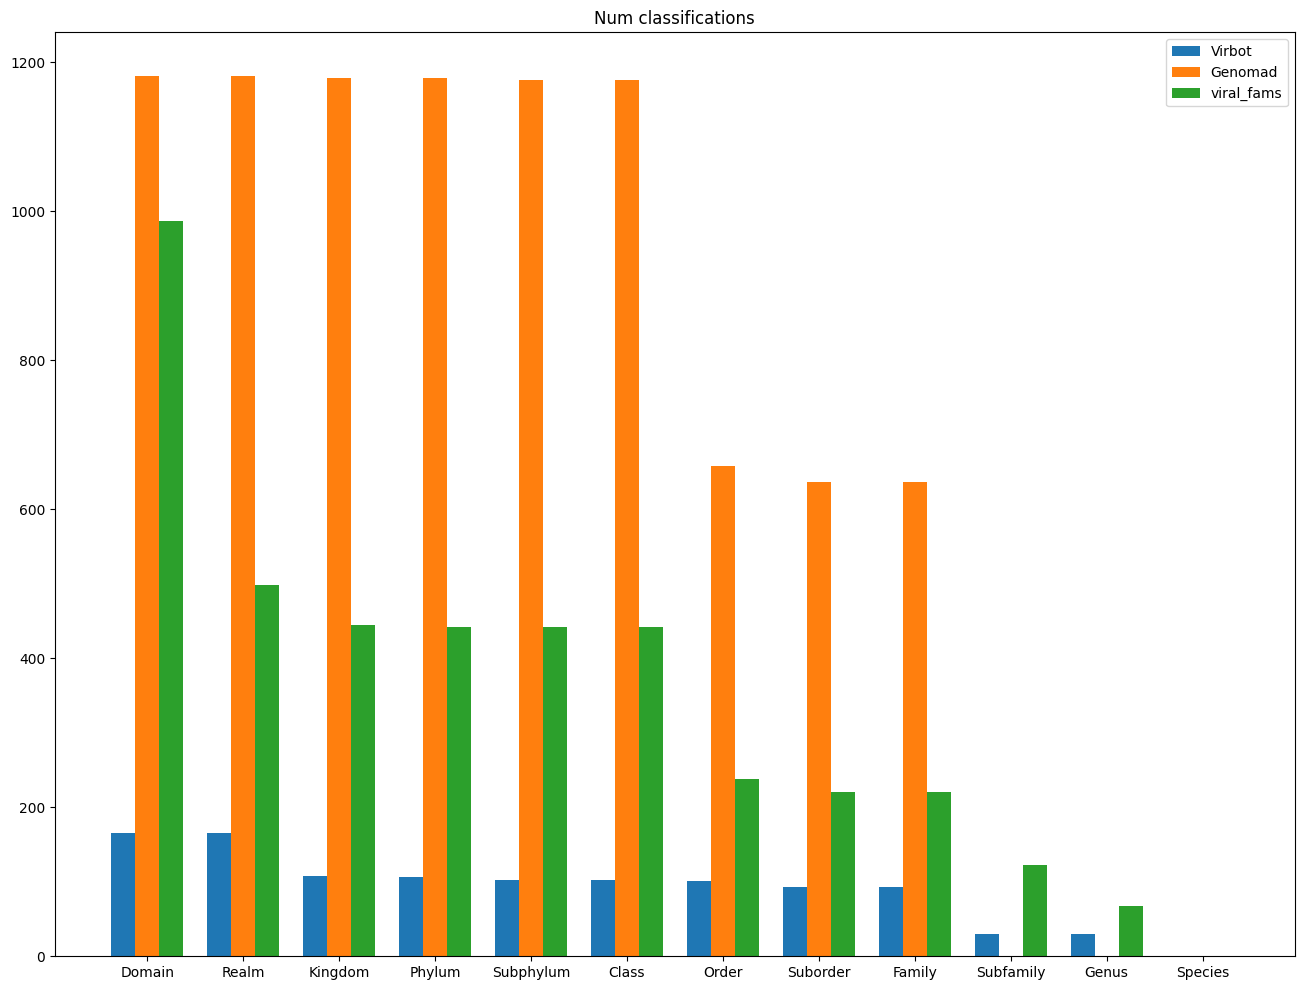

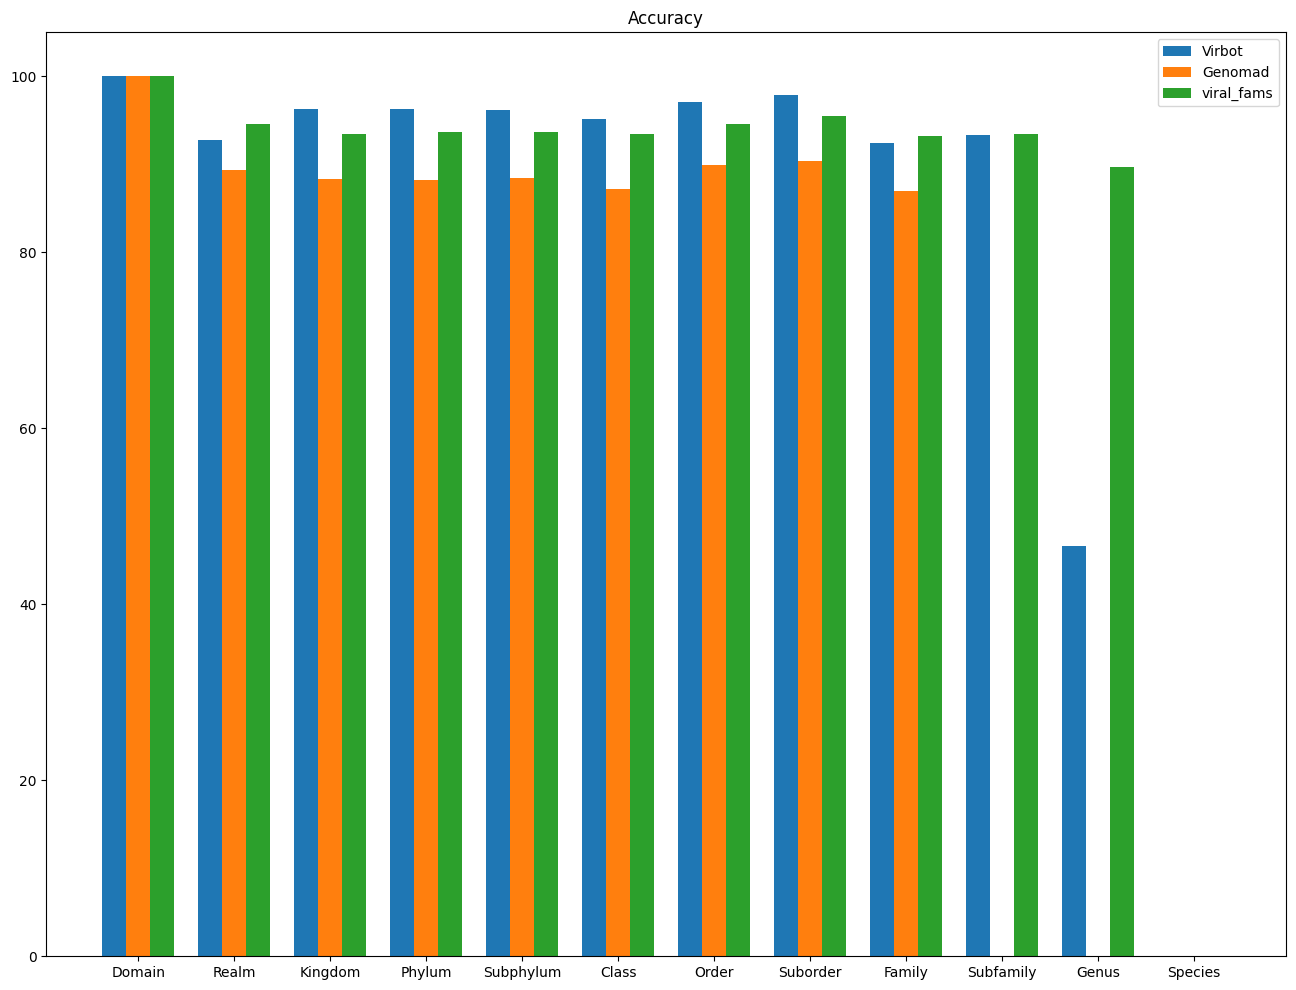

In [285]:
def plot_three_bars(virbot_array, genomad_array, viral_fams_array, title):
    x = np.arange(len(ORDERED_TAXA_RANKS))
    width = 0.25
    fig, ax = plt.subplots(figsize=(16,12))
    rects1 = ax.bar(x - width, virbot_array, width, label='Virbot')
    rects2 = ax.bar(x, genomad_array, width, label='Genomad')
    rects3 = ax.bar(x + width, viral_fams_array, width, label='viral_fams')
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(ORDERED_TAXA_RANKS)
    ax.legend()

    plt.show()

plot_three_bars(virbot_classifications, genomad_classifications, viral_fams_classifications, "Num classifications")
plot_three_bars(virbot_accuracies, genomad_accuracies, viral_fams_accuracies, "Accuracy")

In [286]:
# compare specificity
def compare_specificity(predictions_1, name_1, predictions_2, name_2):
    all_contigs = set(predictions_1.keys()).union(set(predictions_2))

    num_same = 0
    num_same_virbot_more_specific = 0
    num_same_viral_fams_more_specific = 0
    num_different = 0

    num_not_in_virbot = 0
    num_not_in_viral_fams = 0

    for contig in all_contigs:
        virbot_taxa = None
        viral_fams_taxa = None

        if contig in predictions_1.keys():
            virbot_taxa = predictions_1[contig].split("; ")
            virbot_taxa_len = len(virbot_taxa)
        else:
            num_not_in_virbot += 1

        if contig in predictions_2.keys():
            viral_fams_taxa = predictions_2[contig].split("; ")
            viral_fams_taxa_len = len(viral_fams_taxa)
        else:
            num_not_in_viral_fams += 1

        if virbot_taxa and viral_fams_taxa:
            shorter_taxa = virbot_taxa
            longer_taxa = viral_fams_taxa

            if virbot_taxa_len > viral_fams_taxa_len:
                shorter_taxa = viral_fams_taxa
                longer_taxa = virbot_taxa

            if all([tax in longer_taxa for tax in shorter_taxa]):
                num_same += 1

                if virbot_taxa_len < viral_fams_taxa_len:
                    num_same_viral_fams_more_specific += 1
                elif virbot_taxa_len > viral_fams_taxa_len:
                    num_same_virbot_more_specific += 1
            else:
                # print(contig)
                # print(shorter_taxa)
                # print(longer_taxa)
                num_different += 1
                
    print(f"Same:\t{round((num_same / len(all_contigs) if len(all_contigs) != 0 else 0) * 100, 2)}%")
    print(f"Same ({name_1} more specific):\t{round((num_same_virbot_more_specific / num_same if num_same != 0 else 0) * 100, 2)}%")
    print(f"Same ({name_2} more specific):\t{round((num_same_viral_fams_more_specific / num_same if num_same != 0 else 0) * 100, 2)}%")

    print(f"Different:\t{round((num_different / len(all_contigs) if len(all_contigs) != 0 else 0) * 100, 2)}%")

    print(f"Not identified by {name_1}:\t{round((num_not_in_virbot / len(all_contigs if len(all_contigs) != 0 else 0)) * 100, 2)}%")
    print(f"Not identified by {name_2}:\t{round((num_not_in_viral_fams / len(all_contigs) if len(all_contigs) != 0 else 0) * 100, 2)}%")

In [287]:
compare_specificity(virbot_predictions, "virbot", viral_fams_predictions, "viral_fams")


Same:	12.66%
Same (virbot more specific):	79.07%
Same (viral_fams more specific):	10.85%
Different:	0.49%
Not identified by virbot:	83.71%
Not identified by viral_fams:	3.14%


In [288]:
compare_specificity(genomad_predictions, "genomad", viral_fams_predictions, "viral_fams")

Same:	81.07%
Same (genomad more specific):	64.36%
Same (viral_fams more specific):	13.43%
Different:	1.26%
Not identified by genomad:	0.34%
Not identified by viral_fams:	17.34%


In [289]:
compare_specificity(virbot_predictions, "virbot", genomad_predictions, "genomad")

Same:	12.08%
Same (virbot more specific):	17.36%
Same (genomad more specific):	45.14%
Different:	1.68%
Not identified by virbot:	86.07%
Not identified by genomad:	0.17%
